# Phase 1 — Exploratory Data Analysis
**Goal:** Visualise cycling patterns across time, space, and site characteristics.

Requires: `data/processed/cyclists_clean.parquet` (run `01_data_loading.ipynb` first).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROC_DIR = Path('../data/processed')
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_parquet(PROC_DIR / 'cyclists_clean.parquet')
print('Loaded:', df.shape)

Loaded: (37488307, 27)


## 1. Annual & Monthly Trends

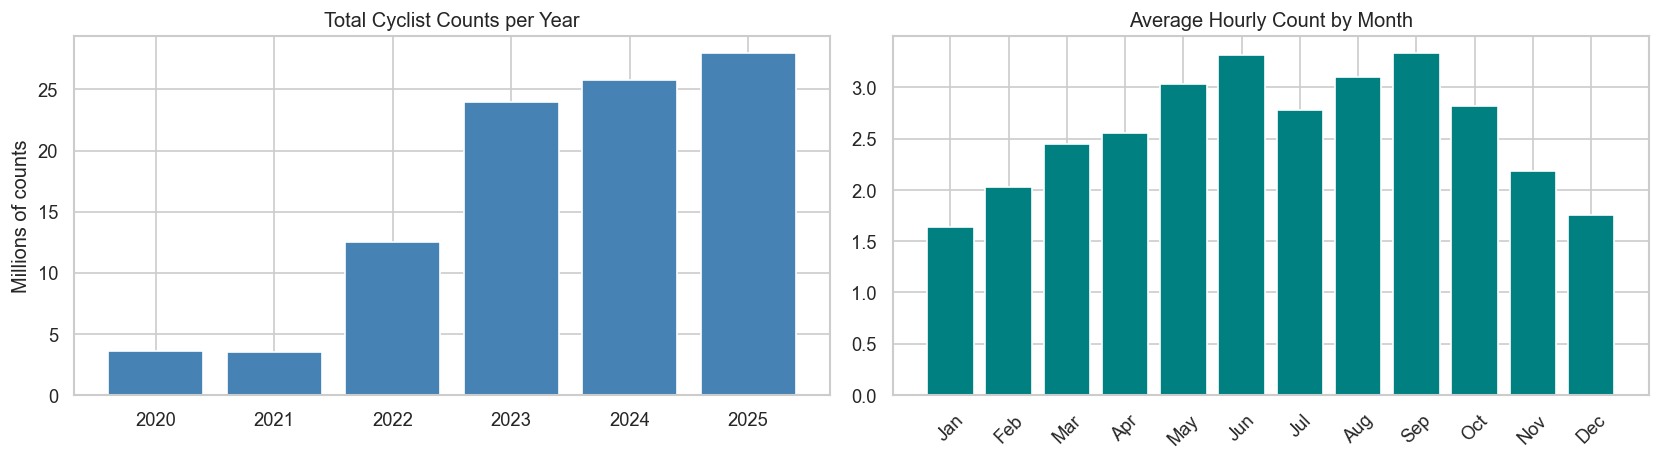

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

yearly = df.groupby('year')['aantal'].sum().reset_index()
axes[0].bar(yearly['year'], yearly['aantal'] / 1e6, color='steelblue')
axes[0].set_title('Total Cyclist Counts per Year')
axes[0].set_ylabel('Millions of counts')

monthly = df.groupby('month')['aantal'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly['month'], monthly['aantal'], color='teal')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_title('Average Hourly Count by Month')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig01_annual_monthly.png', bbox_inches='tight')
plt.show()

## 2. Hourly Profile by Day of Week

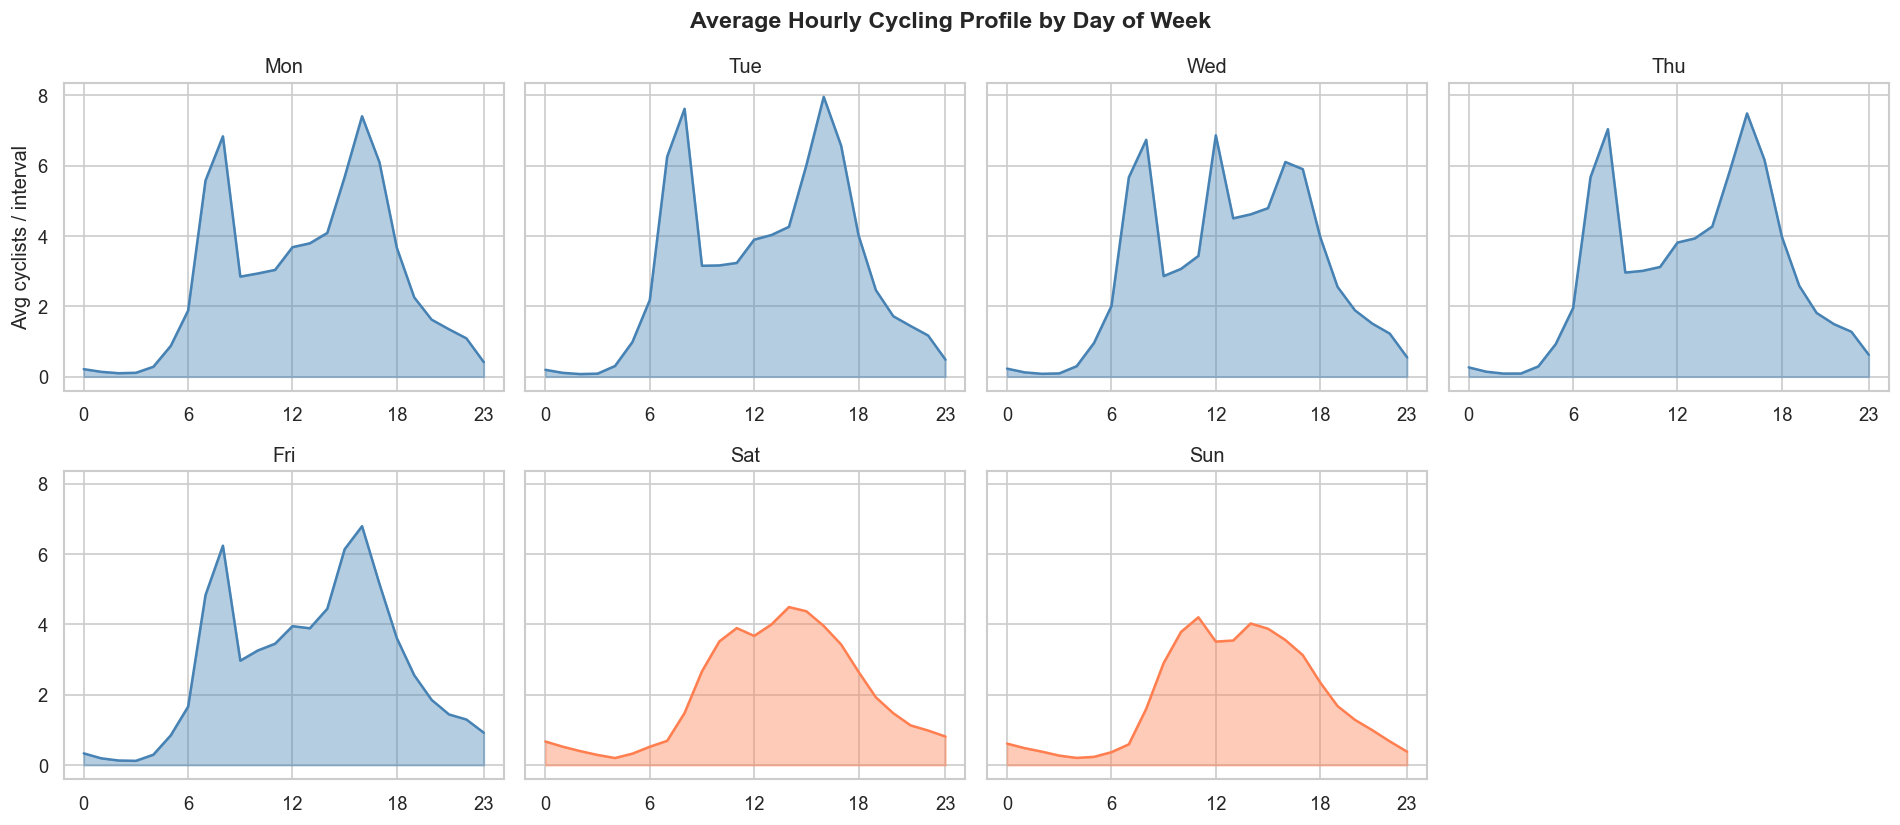

In [3]:
hourly_dow = df.groupby(['day_of_week', 'hour'])['aantal'].mean().reset_index()
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
axes = axes.flatten()
colors = ['steelblue']*5 + ['coral']*2

for i, (dow, label) in enumerate(zip(range(7), day_labels)):
    data = hourly_dow[hourly_dow['day_of_week'] == dow]
    axes[i].fill_between(data['hour'], data['aantal'], alpha=0.4, color=colors[i])
    axes[i].plot(data['hour'], data['aantal'], color=colors[i])
    axes[i].set_title(label)
    axes[i].set_xticks([0,6,12,18,23])

axes[0].set_ylabel('Avg cyclists / interval')
axes[7].axis('off')
fig.suptitle('Average Hourly Cycling Profile by Day of Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig02_hourly_dow.png', bbox_inches='tight')
plt.show()

## 3. Heatmap: Hour of Day × Day of Week

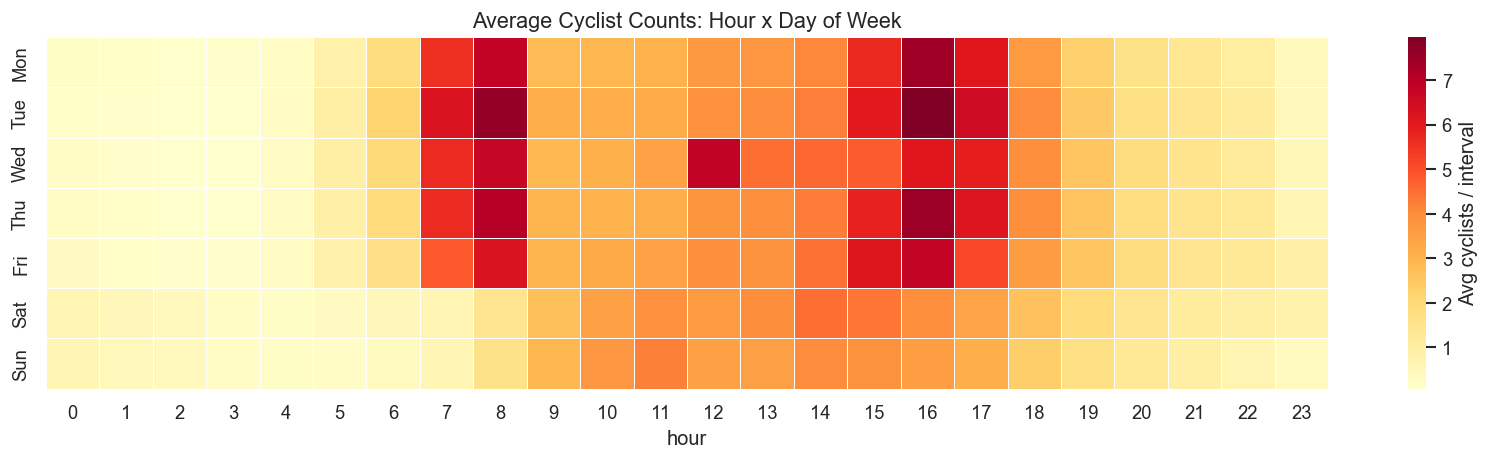

In [4]:
pivot = df.groupby(['day_of_week', 'hour'])['aantal'].mean().unstack('hour')
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Avg cyclists / interval'})
ax.set_title('Average Cyclist Counts: Hour x Day of Week', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig03_heatmap_hour_dow.png', bbox_inches='tight')
plt.show()

## 4. Weekday vs. Weekend

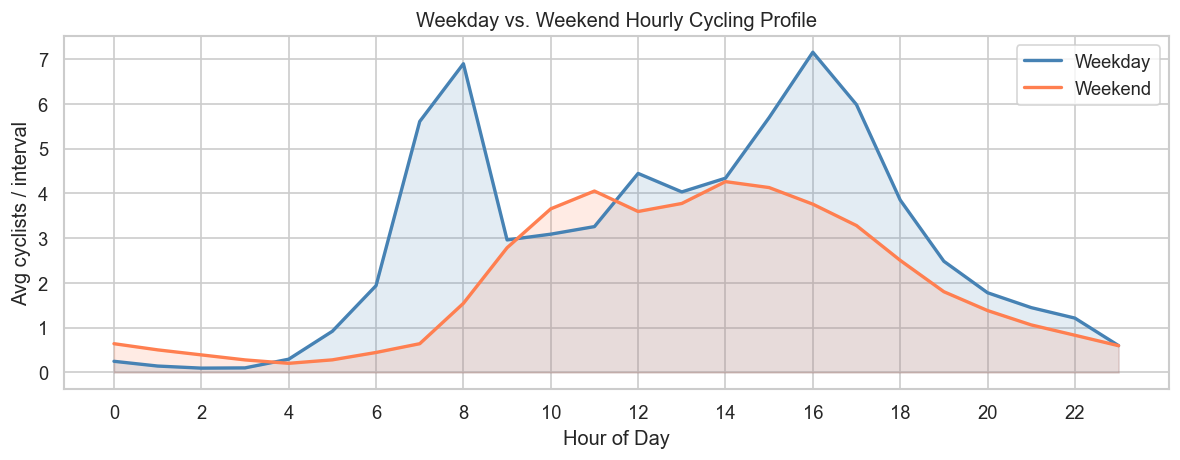

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
hourly_we = df.groupby(['is_weekend', 'hour'])['aantal'].mean().reset_index()
for flag, label, color in [(0,'Weekday','steelblue'), (1,'Weekend','coral')]:
    d = hourly_we[hourly_we['is_weekend'] == flag]
    ax.plot(d['hour'], d['aantal'], label=label, color=color, linewidth=2)
    ax.fill_between(d['hour'], d['aantal'], alpha=0.15, color=color)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg cyclists / interval')
ax.set_title('Weekday vs. Weekend Hourly Cycling Profile')
ax.legend()
ax.set_xticks(range(0,24,2))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig04_weekday_vs_weekend.png', bbox_inches='tight')
plt.show()

## 5. Top 15 Municipalities by Total Cycling Count

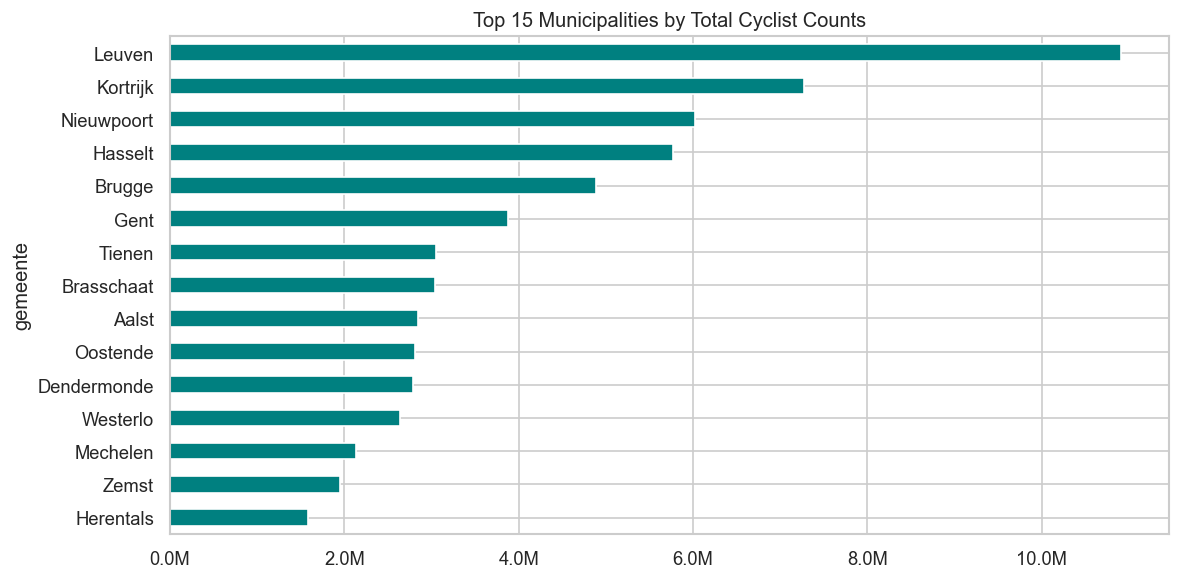

In [6]:
gemeente_col = 'gemeente' if 'gemeente' in df.columns else None
if gemeente_col:
    top_gem = (df.groupby(gemeente_col)['aantal'].sum()
               .sort_values(ascending=False).head(15))
    fig, ax = plt.subplots(figsize=(10, 5))
    top_gem.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 15 Municipalities by Total Cyclist Counts')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig05_top_municipalities.png', bbox_inches='tight')
    plt.show()

## 6. Holiday vs. Non-Holiday

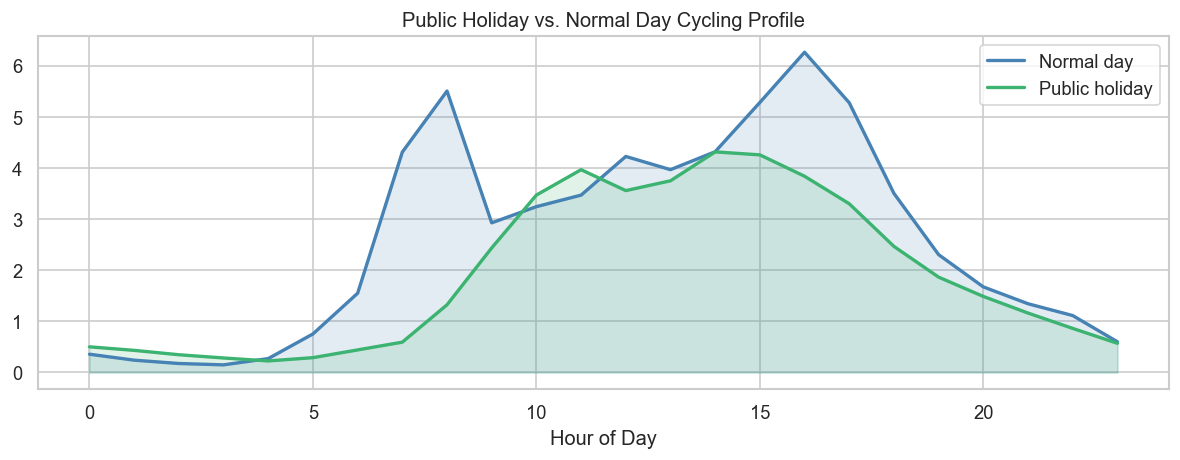

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
hourly_hol = df.groupby(['is_holiday', 'hour'])['aantal'].mean().reset_index()
for flag, label, color in [(0,'Normal day','steelblue'), (1,'Public holiday','mediumseagreen')]:
    d = hourly_hol[hourly_hol['is_holiday'] == flag]
    ax.plot(d['hour'], d['aantal'], label=label, color=color, linewidth=2)
    ax.fill_between(d['hour'], d['aantal'], alpha=0.15, color=color)
ax.set_xlabel('Hour of Day')
ax.legend()
ax.set_title('Public Holiday vs. Normal Day Cycling Profile')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig06_holiday_vs_normal.png', bbox_inches='tight')
plt.show()

## 7. Season Profiles

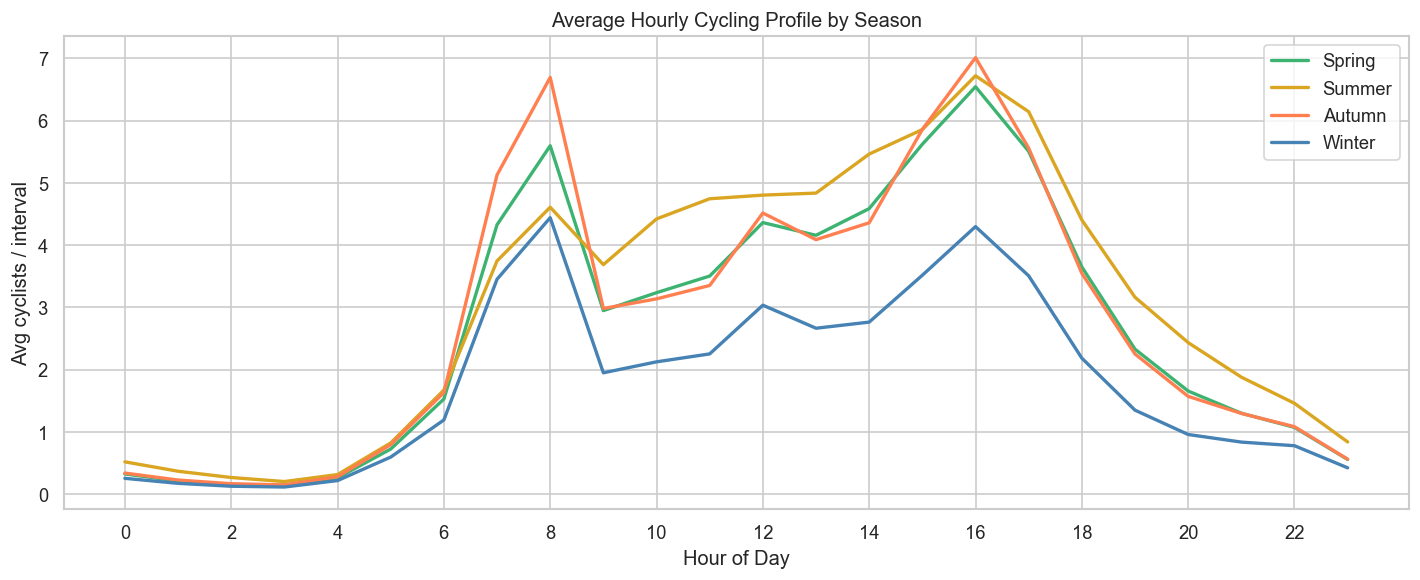

In [8]:
season_order = ['Spring','Summer','Autumn','Winter']
season_avg = df.groupby(['season','hour'])['aantal'].mean().reset_index()
season_colors = {'Spring':'mediumseagreen','Summer':'goldenrod','Autumn':'coral','Winter':'steelblue'}

fig, ax = plt.subplots(figsize=(12, 5))
for s in season_order:
    d = season_avg[season_avg['season'] == s]
    ax.plot(d['hour'], d['aantal'], label=s, color=season_colors[s], linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg cyclists / interval')
ax.set_title('Average Hourly Cycling Profile by Season')
ax.legend()
ax.set_xticks(range(0,24,2))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig07_season_profiles.png', bbox_inches='tight')
plt.show()